# Manual / visual inspection of crypt segmentation

Single-notebook workflow to **filter and visually inspect** crypt segmentations.

It:
- scans graphs + segmentations
- builds an in-memory table of per-organoid summary stats
- filters by timepoint, number of crypts, marker presence (organoid-wide or crypt-only), and future shape complexity
- plots organoids with nodes colored by markers and crypt regions highlighted

Backends:
- `plotly` (interactive)
- `mpl3d` (lightweight static 3D)
- `orthoprojs` (3-panel orthographic QC)

In [233]:
# If you edit paths, re-run this cell and everything below.
import os, glob
import numpy as np
import pandas as pd

# Optional: widgets (nice UX, but notebook still works without them)
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    HAS_WIDGETS = True
except Exception:
    HAS_WIDGETS = False

import organograph
from organograph.graph.io import load_cell_graph
from organograph.graph.access import graph_get, graph_get_meta, graph_get_marker_bin

# Plotting (expects your backend-enabled plotting)
from organograph.plotting.graphs import *

# -----------------------
# CONFIG (edit these)
# -----------------------
DATASET      = "20250929" 

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

SEG_DIR      = os.path.join(PROJECT_ROOT, "..", "NicoleData", DATASET, "crypt_segmentations_graph")
GRAPHS_DIR   = os.path.join(PROJECT_ROOT, "..", "NicoleData", DATASET, "graphs_preprocessed")


# Timepoints to consider (None -> auto-discover from GRAPHS_DIR)
TIMEPOINTS = ['day3p5'] #["day4p5"]  # or None



In [234]:
from organograph.io_utils.dataset_config import load_cell_table_config

CELL_CONFIG_PATH= os.path.join(PROJECT_ROOT, "..", "NicoleData", DATASET, "cell_table_config.json")
cell_cfg    = load_cell_table_config(CELL_CONFIG_PATH)

MARKER_NAMES = list(cell_cfg["marker_names"])

print("MARKER_NAMES =", MARKER_NAMES)

i_LGR5 = MARKER_NAMES.index("LGR5")
i_AldoB = MARKER_NAMES.index("AldoB")
i_Sero = MARKER_NAMES.index("Serotonin")
i_Lyso = MARKER_NAMES.index("Lysozyme")

MARKER_NAMES = ['LGR5', 'Chroma', 'Cyclin D', 'Mucin 2', 'AldoB', 'Glucagon', 'Cyclin A', 'Agr2', 'Serotonin', 'Lysozyme']


In [235]:
from organograph.crypts.filters import filter_crypts_by_markers

crypt_filter = lambda G, crypts_graph, seg: filter_crypts_by_markers(
    G,
    crypts_graph,
    pos_markers=[],
    neg_markers=[],
    pos_min=3,
    neg_min=3,
    roi_frac=0.3,
    dist_bottom=seg["d_crypts_graph"],
    require_all_pos=True,
)

## Utilities

In [236]:
def discover_timepoints(seg_dir):
    if not os.path.isdir(seg_dir):
        return []
    tps = []
    for name in sorted(os.listdir(seg_dir)):
        p = os.path.join(seg_dir, name)
        if os.path.isdir(p) and glob.glob(os.path.join(p, "*.npz")):
            tps.append(name)
    return tps

def _seg_get(seg, *keys, default=None):
    """Return the first existing key from seg."""
    for k in keys:
        if k in seg:
            return seg[k]
    return default


def _safe_array(x):
    if x is None:
        return None
    return np.asarray(x)


def _as_list_of_lists(x):
    """
    Normalize stored crypt list from npz/object-array into a Python list[list[int]].
    """
    if x is None:
        return []
    if isinstance(x, list):
        return [list(xx) for xx in x]
    if isinstance(x, np.ndarray) and x.dtype == object:
        return [list(xx) for xx in x.tolist()]
    return [list(xx) for xx in x]


def _infer_marker_names(G, marker_names=None):
    """
    Try to infer marker names from the graph if not provided.
    """
    if marker_names is not None:
        return list(marker_names)

    # common places where this may live
    for k in ["marker_names", "markers", "marker_cols"]:
        v = G.graph.get(k, None)
        if v is not None:
            return list(v)

    # fall back to shape only
    markers_bin = graph_get(G, "markers_bin")
    n_markers = markers_bin.shape[1]
    return [f"marker_{i}" for i in range(n_markers)]


def _infer_label_uid(G, fallback=None):
    return G.graph.get("label_uid", None) or fallback


In [237]:
def get_marker_counts_per_patch(G, patch):
    markers_bin = graph_get(G, "markers_bin")
    idx = np.fromiter(patch, dtype=np.int64)
    num_pos_cells = np.sum(markers_bin[idx, :], axis=0).astype(np.int64)
    num_cells = len(idx)
    return num_pos_cells, num_cells


def assign_coexpression_category(G, patch, i_LGR5, i_Sero, i_Lyso, pos_threshold=1):
    markers_bin = graph_get(G, "markers_bin")
    idx = np.fromiter(patch, dtype=np.int64)
    bin_markers_patch = markers_bin[idx, :]

    has_marker = np.sum(bin_markers_patch, axis=0) >= pos_threshold

    # Write out full co-expression conditions (same style as marker_coexpression)
    c0 = has_marker[i_LGR5] and has_marker[i_Sero] and (not has_marker[i_Lyso])
    c1 = has_marker[i_LGR5] and has_marker[i_Lyso] and (not has_marker[i_Sero])
    c2 = has_marker[i_LGR5] and (not has_marker[i_Lyso]) and (not has_marker[i_Sero])
    c3 = has_marker[i_LGR5] and (has_marker[i_Lyso] and has_marker[i_Sero])

    c4 = (not has_marker[i_LGR5]) and has_marker[i_Sero] and (not has_marker[i_Lyso])
    c5 = (not has_marker[i_LGR5]) and has_marker[i_Lyso] and (not has_marker[i_Sero])
    c6 = (not has_marker[i_LGR5]) and (not has_marker[i_Lyso]) and (not has_marker[i_Sero])
    c7 = (not has_marker[i_LGR5]) and (has_marker[i_Lyso] and has_marker[i_Sero])

    # Convert the one-hot-ish conditions to a single index.
    # These should be mutually exclusive and cover all cases.
    conds = np.array([c0, c1, c2, c3, c4, c5, c6, c7], dtype=np.int64)

    hits = np.flatnonzero(conds)
    if hits.size == 1:
        return int(hits[0])
    else:
        return np.nan

In [238]:

from organograph.io_utils.segmentation_io import load_graph_crypt_segmentation

def build_inspection_table(
    seg_dir,
    timepoints=None,
    verbose=True,
    marker_names=None,
    min_positive=1,
    pos_threshold=1,
    i_LGR5=None,
    i_Sero=None,
    i_Lyso=None,
    crypt_filter=None,
):
    if timepoints is None:
        timepoints = discover_timepoints(seg_dir)

    rows_out = []

    for tp in timepoints:
        tp_dir = os.path.join(seg_dir, tp)
        for seg_path in sorted(glob.glob(os.path.join(tp_dir, "*.npz"))):

            # load segmentation
            try:
                seg = load_graph_crypt_segmentation(seg_path)
            except Exception as e:
                if verbose:
                    print(f"[skip] could not load segmentation {seg_path}: {e}")
                continue

            # load graph
            try:
                G = load_cell_graph(seg["graph_path"])
            except Exception as e:
                if verbose:
                    print(f"[skip] could not load graph {seg.get('graph_path', None)}: {e}")
                continue

            crypts_graph = _as_list_of_lists(
                _seg_get(seg, "crypts_graph", "crypts_ll", "graph_crypts_ll", default=[])
            )
            constrictions = _safe_array(_seg_get(seg, "crypt_constrictions", default=None))
            elongations = _safe_array(_seg_get(seg, "crypt_elongations", "crypt_elongationss", default=None))
            graph_patch_sizes = _safe_array(_seg_get(seg, "graph_patch_sizes", default=None))

            label_uid = _seg_get(seg, "label_uid", default=None)
            label_uid = _infer_label_uid(G, fallback=label_uid)

            cur_marker_names = _infer_marker_names(G, marker_names=marker_names)
            n_markers = len(cur_marker_names)

            n_crypts = len(crypts_graph)

            print("shape circumference_crypts: ", seg["circumference_crypts"].shape)
            print("shape crypt_constrictions: ", seg["crypt_constrictions"].shape)
            print("shape crypt dist: ", seg["d_crypts_graph"].shape)
            print("number of crypts: ", n_crypts)
            print("number of cells: ", G.number_of_nodes())

            # ---------------------------
            # run filter once
            # ---------------------------
            if crypt_filter is None:
                keep_idx = np.arange(n_crypts, dtype=np.int64)
            else:
                keep = crypt_filter(G, crypts_graph, seg)

                if isinstance(keep, np.ndarray) and keep.dtype == bool:
                    if len(keep) != n_crypts:
                        raise ValueError(
                            f"crypt_filter returned boolean mask of length {len(keep)}, "
                            f"expected {n_crypts}"
                        )
                    keep_idx = np.flatnonzero(keep)

                else:
                    keep_idx = np.asarray(keep, dtype=np.int64)

            # optional sanity checks
            if keep_idx.ndim != 1:
                raise ValueError("keep_idx must be a 1D array of crypt indices")
            if len(keep_idx) > 0:
                if keep_idx.min() < 0 or keep_idx.max() >= n_crypts:
                    raise ValueError("crypt_filter returned out-of-range crypt indices")

            # ---------------------------
            # subset all aligned per-crypt data
            # ---------------------------
            crypts_graph_f = [crypts_graph[j] for j in keep_idx]
            constrictions_f = constrictions[keep_idx] if constrictions is not None else None
            elongations_f = elongations[keep_idx] if elongations is not None else None
            graph_patch_sizes_f = graph_patch_sizes[keep_idx] if graph_patch_sizes is not None else None

            # keep original crypt ids for traceability
            orig_crypt_numbers_f = keep_idx

            # ---------------------------
            # iterate over filtered crypts
            # ---------------------------
            for local_idx, crypt_cells in enumerate(crypts_graph_f):

                crypt_cells = list(crypt_cells)
                if len(crypt_cells) == 0:
                    continue

                orig_j = int(orig_crypt_numbers_f[local_idx])

                num_pos_cells, num_cells = get_marker_counts_per_patch(G, crypt_cells)
                num_pos_cells = np.asarray(num_pos_cells, dtype=np.int64)

                if num_pos_cells.shape[0] != n_markers:
                    raise ValueError(
                        f"Marker count mismatch for {seg_path}: "
                        f"counts have length {num_pos_cells.shape[0]}, "
                        f"marker_names has length {n_markers}"
                    )

                has_marker = (num_pos_cells >= min_positive).astype(np.int64)

                if None not in (i_LGR5, i_Sero, i_Lyso):
                    cat = assign_coexpression_category(
                        G,
                        crypt_cells,
                        i_LGR5,
                        i_Sero,
                        i_Lyso,
                        pos_threshold=pos_threshold,
                    )
                else:
                    cat = np.nan

                constr = (
                    float(constrictions_f[local_idx])
                    if constrictions_f is not None and local_idx < len(constrictions_f)
                    else np.nan
                )

                row = {
                    "timepoint": tp,
                    "label_uid": label_uid,
                    "crypt_number": orig_j,              # original index in segmentation
                    "crypt_number_filtered": local_idx,  # index within filtered subset
                    "graph_path": seg.get("graph_path", None),
                    "mesh_path": seg.get("mesh_path", None),
                    "seg_path": seg_path if os.path.exists(seg_path) else None,
                    "has_seg": bool(os.path.exists(seg_path)),
                    "num_cells": int(num_cells),
                    "constriction": constr,
                    "elongation": (
                        float(elongations_f[local_idx])
                        if elongations_f is not None and local_idx < len(elongations_f)
                        else np.nan
                    ),
                    "graph_patch_size": (
                        int(graph_patch_sizes_f[local_idx])
                        if graph_patch_sizes_f is not None and local_idx < len(graph_patch_sizes_f)
                        else int(num_cells)
                    ),
                    "coexpression_cat": cat,
                    "is_budded": (constr > 0) if not np.isnan(constr) else np.nan,
                }

                for k, mk in enumerate(cur_marker_names):
                    row[f"{mk}_n_pos"] = int(num_pos_cells[k])
                    row[f"{mk}_frac_pos"] = float(num_pos_cells[k] / num_cells) if num_cells > 0 else np.nan
                    row[f"{mk}_has"] = int(has_marker[k])

                rows_out.append(row)

    df = pd.DataFrame(rows_out)

    if len(df) == 0:
        return df

    has_cols = [c for c in df.columns if c.endswith("_has")]
    df["n_markers_present"] = df[has_cols].sum(axis=1)

    return df

In [239]:
inspection_df = build_inspection_table(
    seg_dir=SEG_DIR,
    min_positive=1,
    pos_threshold=1,
    i_LGR5=i_LGR5,
    i_Sero=i_Sero,
    i_Lyso=i_Lyso,
    crypt_filter=crypt_filter,
)

inspection_df.head()

shape circumference_crypts:  (0, 150)
shape crypt_constrictions:  (0,)
shape crypt dist:  (0, 165)
number of crypts:  0
number of cells:  165
shape circumference_crypts:  (0, 150)
shape crypt_constrictions:  (0,)
shape crypt dist:  (0, 228)
number of crypts:  0
number of cells:  228
shape circumference_crypts:  (0, 150)
shape crypt_constrictions:  (0,)
shape crypt dist:  (0, 179)
number of crypts:  0
number of cells:  179
shape circumference_crypts:  (2, 150)
shape crypt_constrictions:  (2,)
shape crypt dist:  (2, 239)
number of crypts:  2
number of cells:  239
shape circumference_crypts:  (2, 150)
shape crypt_constrictions:  (2,)
shape crypt dist:  (2, 163)
number of crypts:  2
number of cells:  163
shape circumference_crypts:  (2, 150)
shape crypt_constrictions:  (2,)
shape crypt dist:  (2, 255)
number of crypts:  2
number of cells:  255
shape circumference_crypts:  (0, 150)
shape crypt_constrictions:  (0,)
shape crypt dist:  (0, 119)
number of crypts:  0
number of cells:  119
shape 

,timepoint,label_uid,crypt_number,crypt_number_filtered,graph_path,mesh_path,seg_path,has_seg,num_cells,constriction,...,Agr2_n_pos,Agr2_frac_pos,Agr2_has,Serotonin_n_pos,Serotonin_frac_pos,Serotonin_has,Lysozyme_n_pos,Lysozyme_frac_pos,Lysozyme_has,n_markers_present
0,day3p5,day3p5_A01_12,0,0,/home/fmoller/Projects/LearningOrganoids/Organ...,/home/fmoller/Projects/LearningOrganoids/Nicol...,/home/fmoller/Projects/LearningOrganoids/Organ...,True,61,0.000000,...,9,0.147541,1,0,0.000000,0,2,0.032787,1,6
1,day3p5,day3p5_A01_12,1,1,/home/fmoller/Projects/LearningOrganoids/Organ...,/home/fmoller/Projects/LearningOrganoids/Nicol...,/home/fmoller/Projects/LearningOrganoids/Organ...,True,21,0.000000,...,3,0.142857,1,0,0.000000,0,3,0.142857,1,5
2,day3p5,day3p5_A01_13,0,0,/home/fmoller/Projects/LearningOrganoids/Organ...,/home/fmoller/Projects/LearningOrganoids/Nicol...,/home/fmoller/Projects/LearningOrganoids/Organ...,True,66,0.000000,...,7,0.106061,1,0,0.000000,0,4,0.060606,1,5
3,day3p5,day3p5_A01_13,1,1,/home/fmoller/Projects/LearningOrganoids/Organ...,/home/fmoller/Projects/LearningOrganoids/Nicol...,/home/fmoller/Projects/LearningOrganoids/Organ...,True,68,0.000011,...,9,0.132353,1,2,0.029412,1,6,0.088235,1,7
4,day3p5,day3p5_A01_16,0,0,/home/fmoller/Projects/LearningOrganoids/Organ...,/home/fmoller/Projects/LearningOrganoids/Nicol...,/home/fmoller/Projects/LearningOrganoids/Organ...,True,40,0.000000,...,8,0.200000,1,1,0.025000,1,9,0.225000,1,9


## Build inspection table

## Filtering

In [240]:
import matplotlib.pyplot as plt

def plot_fraction_of_crypts_with_marker(
    inspection_df,
    marker_names=None,
    constriction_col="constriction",
    figsize=(10, 5),
    normalize_within_group=True,
):
    """
    For each marker, plot the fraction of crypts where that marker is present.
    Bars are stacked into:
      - bulged: constriction == 0
      - budded: constriction > 0

    If normalize_within_group=True:
        bulged height  = (# bulged crypts with marker) / (total # crypts)
        budded height  = (# budded crypts with marker) / (total # crypts)
        total bar      = overall fraction of crypts with marker

    If normalize_within_group=False:
        same result here in practice because both parts are fractions of all crypts.
        I kept the flag only for future flexibility.
    """
    df = inspection_df.copy()

    if marker_names is None:
        marker_names = [c[:-4] for c in df.columns if c.endswith("_has")]

    if len(df) == 0:
        raise ValueError("inspection_df is empty")

    budded = df[constriction_col] > 0
    bulged = df[constriction_col] == 0
    n_total = len(df)

    bulged_vals = []
    budded_vals = []

    for mk in marker_names:
        col = f"{mk}_has"
        if col not in df.columns:
            raise KeyError(f"Missing column: {col}")

        bulged_vals.append(df.loc[bulged, col].sum() / n_total)
        budded_vals.append(df.loc[budded, col].sum() / n_total)

    x = np.arange(len(marker_names))

    plt.figure(figsize=figsize)
    plt.bar(x, bulged_vals, label="bulged (constriction = 0)")
    plt.bar(x, budded_vals, bottom=bulged_vals, label="budded (constriction > 0)")
    plt.xticks(x, marker_names, rotation=45, ha="right")
    plt.ylabel("fraction of crypts")
    plt.title("Fraction of crypts with marker present")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_fraction_of_cells_positive_by_marker(
    inspection_df,
    marker_names=None,
    constriction_col="constriction",
    num_cells_col="num_cells",
    figsize=(10, 5),
):
    """
    For each marker, plot the fraction of cells positive for that marker.

    Two bars per marker:
        - bulged crypts (constriction == 0)
        - budded crypts (constriction > 0)

    Fractions are normalized within each category:
        bulged fraction = positive cells in bulged crypts / total cells in bulged crypts
        budded fraction = positive cells in budded crypts / total cells in budded crypts
    """

    df = inspection_df.copy()

    if marker_names is None:
        marker_names = [c[:-6] for c in df.columns if c.endswith("_n_pos")]

    if len(df) == 0:
        raise ValueError("inspection_df is empty")

    bulged = df[constriction_col] == 0
    budded = df[constriction_col] > 0

    total_cells_bulged = df.loc[bulged, num_cells_col].sum()
    total_cells_budded = df.loc[budded, num_cells_col].sum()

    if total_cells_bulged == 0 or total_cells_budded == 0:
        raise ValueError("One category contains zero cells")

    bulged_vals = []
    budded_vals = []

    for mk in marker_names:

        npos_col = f"{mk}_n_pos"

        if npos_col not in df.columns:
            raise KeyError(f"Missing column: {npos_col}")

        bulged_vals.append(
            df.loc[bulged, npos_col].sum() / total_cells_bulged
        )

        budded_vals.append(
            df.loc[budded, npos_col].sum() / total_cells_budded
        )

    x = np.arange(len(marker_names))
    width = 0.38

    plt.figure(figsize=figsize)

    plt.bar(
        x - width / 2,
        bulged_vals,
        width,
        label="bulged (constriction = 0)",
    )

    plt.bar(
        x + width / 2,
        budded_vals,
        width,
        label="budded (constriction > 0)",
    )

    plt.xticks(x, marker_names, rotation=45, ha="right")
    plt.ylabel("fraction of cells")
    plt.title("Fraction of cells positive for each marker")
    plt.legend()

    plt.tight_layout()
    plt.show()

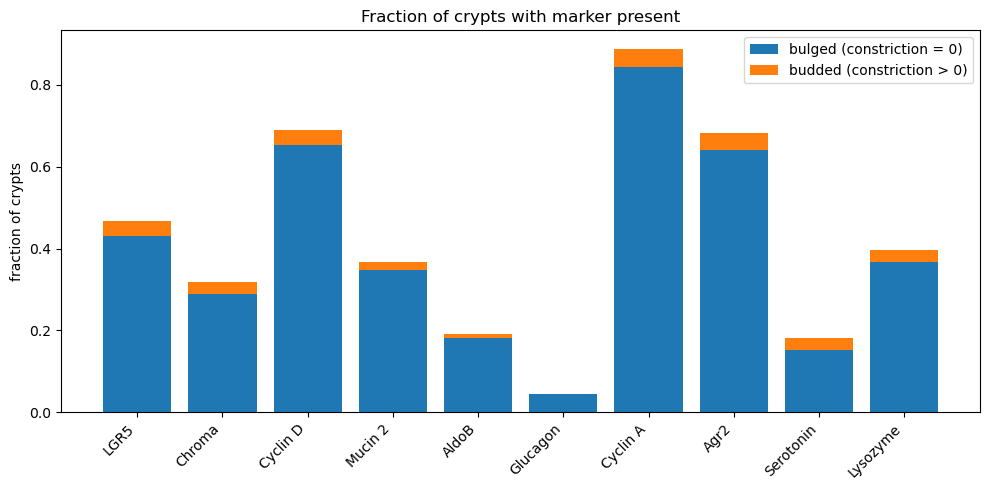

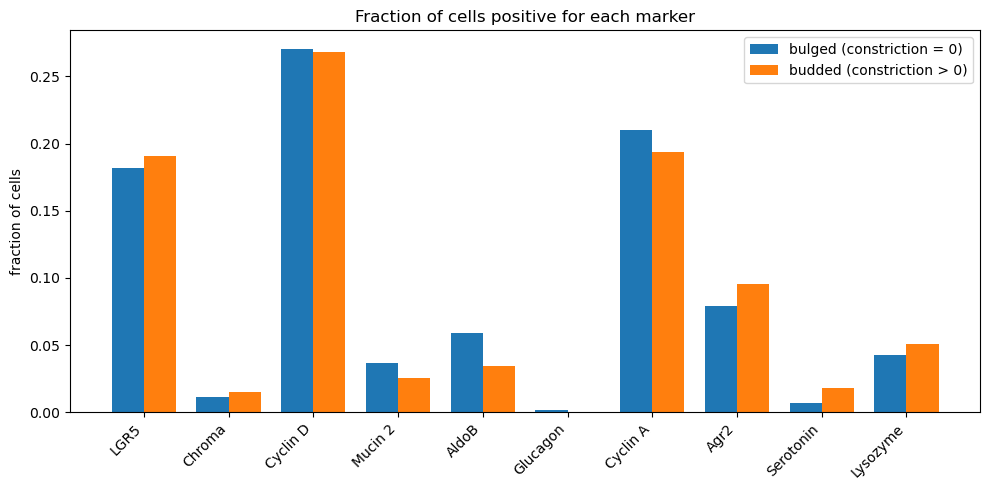

In [241]:
plot_fraction_of_crypts_with_marker(inspection_df)

plot_fraction_of_cells_positive_by_marker(inspection_df)

In [242]:
def _resolve_marker_names_from_table(df, mode="has"):
    if mode == "has":
        return [c[:-4] for c in df.columns if c.endswith("_has")]
    elif mode == "n_pos":
        return [c[:-6] for c in df.columns if c.endswith("_n_pos")]
    else:
        raise ValueError(f"Unknown mode: {mode}")


def _resolve_timepoint_order(df, timepoint_col="timepoint", timepoint_order=None):
    if timepoint_order is not None:
        return list(timepoint_order)
    return list(df[timepoint_col].dropna().unique())


def plot_fraction_of_crypts_with_marker_over_time(
    inspection_df,
    marker_names=None,
    timepoint_col="timepoint",
    constriction_col="constriction",
    timepoint_order=None,
    ncols=2,
    fig_width=7,
    row_height=2.6,
):
    """
    For each marker, plot the fraction of crypts where that marker is present
    as a function of timepoint.

    Each subplot contains two curves:
      - bulged: constriction == 0
      - budded: constriction > 0

    Fractions are normalized within each morphology class at each timepoint:
      bulged fraction = (# bulged crypts with marker) / (# bulged crypts)
      budded fraction = (# budded crypts with marker) / (# budded crypts)
    """
    df = inspection_df.copy()

    if len(df) == 0:
        raise ValueError("inspection_df is empty")

    if marker_names is None:
        marker_names = _resolve_marker_names_from_table(df, mode="has")
    marker_names = list(marker_names)

    timepoints = _resolve_timepoint_order(df, timepoint_col=timepoint_col, timepoint_order=timepoint_order)
    x = np.arange(len(timepoints))

    n_markers = len(marker_names)
    nrows = int(np.ceil(n_markers / ncols))
    fig_height = row_height * nrows

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(fig_width, fig_height),
        sharex=True,
        constrained_layout=True,
    )
    axes = np.atleast_1d(axes).ravel()

    for ax, mk in zip(axes, marker_names):
        col = f"{mk}_has"
        if col not in df.columns:
            raise KeyError(f"Missing column: {col}")

        bulged_vals = []
        budded_vals = []

        for tp in timepoints:
            df_tp = df[df[timepoint_col] == tp]

            bulged = df_tp[constriction_col] == 0
            budded = df_tp[constriction_col] > 0

            n_bulged = bulged.sum()
            n_budded = budded.sum()

            bulged_vals.append(
                df_tp.loc[bulged, col].mean() if n_bulged > 0 else np.nan
            )
            budded_vals.append(
                df_tp.loc[budded, col].mean() if n_budded > 0 else np.nan
            )

        ax.plot(x, bulged_vals, marker="o", linewidth=2, label="bulged")
        ax.plot(x, budded_vals, marker="o", linewidth=2, label="budded")

        ax.set_title(mk, fontweight="bold")
        ax.set_ylabel("fraction of crypts")
        ax.set_ylim(bottom=0)
        ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)

    for ax in axes[n_markers:]:
        ax.axis("off")

    for ax in axes[max(0, len(axes) - ncols):]:
        if ax.has_data():
            ax.set_xlabel("timepoint")
            ax.set_xticks(x)
            ax.set_xticklabels(timepoints, rotation=45, ha="right")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", frameon=False)

    plt.show()


def plot_fraction_of_cells_positive_by_marker_over_time(
    inspection_df,
    marker_names=None,
    timepoint_col="timepoint",
    constriction_col="constriction",
    num_cells_col="num_cells",
    timepoint_order=None,
    ncols=2,
    fig_width=7,
    row_height=2.6,
):
    """
    For each marker, plot the fraction of cells positive for that marker
    as a function of timepoint.

    Each subplot contains two curves:
      - bulged: constriction == 0
      - budded: constriction > 0

    Fractions are normalized within each morphology class at each timepoint:
      bulged fraction = (positive cells in bulged crypts) / (total cells in bulged crypts)
      budded fraction = (positive cells in budded crypts) / (total cells in budded crypts)
    """
    df = inspection_df.copy()

    if len(df) == 0:
        raise ValueError("inspection_df is empty")

    if marker_names is None:
        marker_names = _resolve_marker_names_from_table(df, mode="n_pos")
    marker_names = list(marker_names)

    timepoints = _resolve_timepoint_order(df, timepoint_col=timepoint_col, timepoint_order=timepoint_order)
    x = np.arange(len(timepoints))

    n_markers = len(marker_names)
    nrows = int(np.ceil(n_markers / ncols))
    fig_height = row_height * nrows

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(fig_width, fig_height),
        sharex=True,
        constrained_layout=True,
    )
    axes = np.atleast_1d(axes).ravel()

    for ax, mk in zip(axes, marker_names):
        npos_col = f"{mk}_n_pos"
        if npos_col not in df.columns:
            raise KeyError(f"Missing column: {npos_col}")

        bulged_vals = []
        budded_vals = []

        for tp in timepoints:
            df_tp = df[df[timepoint_col] == tp]

            bulged = df_tp[constriction_col] == 0
            budded = df_tp[constriction_col] > 0

            total_cells_bulged = df_tp.loc[bulged, num_cells_col].sum()
            total_cells_budded = df_tp.loc[budded, num_cells_col].sum()

            bulged_vals.append(
                df_tp.loc[bulged, npos_col].sum() / total_cells_bulged
                if total_cells_bulged > 0 else np.nan
            )
            budded_vals.append(
                df_tp.loc[budded, npos_col].sum() / total_cells_budded
                if total_cells_budded > 0 else np.nan
            )

        ax.plot(x, bulged_vals, marker="o", linewidth=2, label="bulged")
        ax.plot(x, budded_vals, marker="o", linewidth=2, label="budded")

        ax.set_title(mk, fontweight="bold")
        ax.set_ylabel("fraction of cells")
        ax.set_ylim(bottom=0)
        ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)

    for ax in axes[n_markers:]:
        ax.axis("off")

    for ax in axes[max(0, len(axes) - ncols):]:
        if ax.has_data():
            ax.set_xlabel("timepoint")
            ax.set_xticks(x)
            ax.set_xticklabels(timepoints, rotation=45, ha="right")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", frameon=False)

    plt.show()

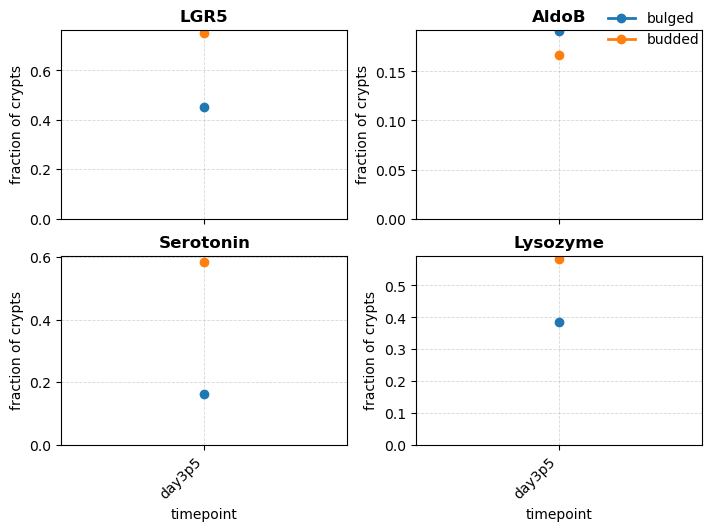

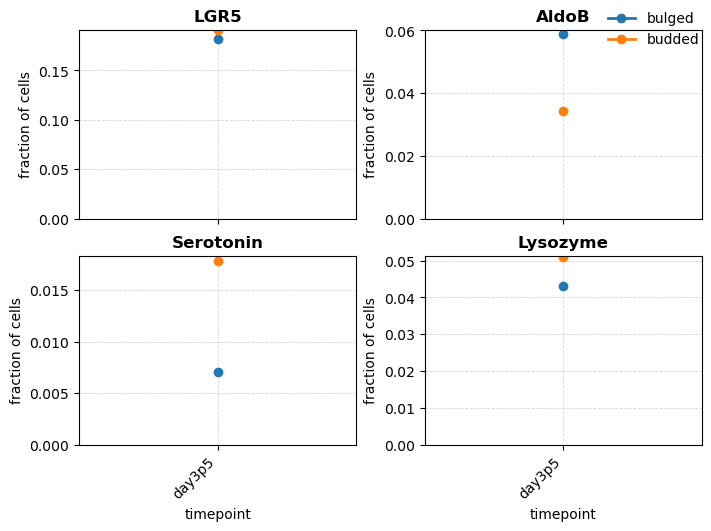

In [243]:
plot_fraction_of_crypts_with_marker_over_time(
    inspection_df,
    marker_names=["LGR5", "AldoB", "Serotonin", "Lysozyme"],
)

plot_fraction_of_cells_positive_by_marker_over_time(
    inspection_df,
    marker_names=["LGR5", "AldoB", "Serotonin", "Lysozyme"],
)

In [244]:
import numpy as np
import matplotlib.pyplot as plt


def expected_coexpression_fractions_within_LGR5_subgroups(
    df_group,
    marker_names,
    i_LGR5,
    i_Sero,
    i_Lyso,
):
    """
    Compute expected coexpression fractions under independence within the
    LGR5+ and LGR5- subgroups separately.

    Returns
    -------
    exp : (8,) array
        Categories 0..3 are conditional within LGR5+ crypts:
          0 = S+ Y-
          1 = Y+ S-
          2 = S- Y-
          3 = S+ Y+

        Categories 4..7 are conditional within LGR5- crypts:
          4 = S+ Y-
          5 = Y+ S-
          6 = S- Y-
          7 = S+ Y+
    """
    col_L = f"{marker_names[i_LGR5]}_has"
    col_S = f"{marker_names[i_Sero]}_has"
    col_Y = f"{marker_names[i_Lyso]}_has"

    exp = np.full(8, np.nan, dtype=float)

    df_pos = df_group[df_group[col_L] == 1]
    df_neg = df_group[df_group[col_L] == 0]

    if len(df_pos) > 0:
        pS_pos = df_pos[col_S].mean()
        pY_pos = df_pos[col_Y].mean()

        exp[0] = pS_pos * (1.0 - pY_pos)          # S+ Y-
        exp[1] = pY_pos * (1.0 - pS_pos)          # Y+ S-
        exp[2] = (1.0 - pS_pos) * (1.0 - pY_pos)  # S- Y-
        exp[3] = pS_pos * pY_pos                  # S+ Y+

    if len(df_neg) > 0:
        pS_neg = df_neg[col_S].mean()
        pY_neg = df_neg[col_Y].mean()

        exp[4] = pS_neg * (1.0 - pY_neg)          # S+ Y-
        exp[5] = pY_neg * (1.0 - pS_neg)          # Y+ S-
        exp[6] = (1.0 - pS_neg) * (1.0 - pY_neg)  # S- Y-
        exp[7] = pS_neg * pY_neg                  # S+ Y+

    return exp


def plot_grouped_bars_with_expected(
    observed,
    expected,
    xtick_labels,
    title,
    group_names,
    figsize=(6, 5),
    dpi=150,
):
    """
    observed: (n_groups, 8)
    expected: (n_groups, 8)

    Two panels:
      - top: categories 0..3, shown as fraction of LGR5+ crypts
      - bottom: categories 4..7, shown as fraction of LGR5- crypts
    """
    observed = np.asarray(observed, float)
    expected = np.asarray(expected, float)

    if observed.shape != expected.shape:
        raise ValueError("observed and expected must have same shape")

    n_groups, K = observed.shape
    if K != 8:
        raise ValueError(f"Expected 8 categories, got {K}")

    idx_pos = np.arange(0, 4)
    idx_neg = np.arange(4, 8)

    w = min(0.22, 0.8 / max(n_groups, 1))
    offsets = (np.arange(n_groups) - (n_groups - 1) / 2) * w

    fig, axes = plt.subplots(
        2, 1,
        figsize=figsize,
        dpi=dpi,
        constrained_layout=True,
        sharey=True,
    )

    def _panel(ax, idxs, ylabel, show_legend=False):
        x = np.arange(4)

        for gi in range(n_groups):
            ax.bar(
                x + offsets[gi],
                observed[gi, idxs],
                width=0.8 * w,
                edgecolor="white",
                linewidth=0.7,
                alpha=0.9,
                label=group_names[gi] if show_legend else None,
                zorder=2,
            )

        for gi in range(n_groups):
            ax.bar(
                x + offsets[gi],
                expected[gi, idxs],
                width=0.8 * w,
                facecolor="none",
                edgecolor="black",
                linewidth=1.3,
                linestyle="--",
                label="Expected (indep.)" if (show_legend and gi == 0) else None,
                zorder=3,
            )

        ax.set_xticks(x)
        ax.set_xticklabels(xtick_labels, rotation=25, ha="right")
        ax.set_ylabel(ylabel)
        ax.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.5)
        ax.set_ylim(bottom=0)

    _panel(axes[0], idx_pos, ylabel="Fraction of LGR5+ crypts", show_legend=True)
    _panel(axes[1], idx_neg, ylabel="Fraction of LGR5- crypts", show_legend=False)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, frameon=False, ncol=min(3, len(labels)), loc="upper right")

    fig.suptitle(title, y=1.02, fontsize=13)
    plt.show()


def aggregate_composition_from_table(df_group, marker_names, i_LGR5, i_Sero, i_Lyso):
    """
    Aggregate one selected group of crypts from inspection_df.

    Returns
    -------
    fp : (M,) marker presence fractions across all crypts in the group
    fcat : (8,) coexpression category fractions, conditional within LGR5+ or LGR5-
           fcat[0:4] sums to 1 over LGR5+ crypts
           fcat[4:8] sums to 1 over LGR5- crypts
    n : int
        Number of crypts in the group
    """
    n = len(df_group)

    if n == 0:
        fp = np.full(len(marker_names), np.nan, dtype=float)
        fcat = np.full(8, np.nan, dtype=float)
        return fp, fcat, 0

    has_cols = [f"{m}_has" for m in marker_names]
    fp = df_group[has_cols].mean(axis=0).to_numpy(dtype=float)

    cat = df_group["coexpression_cat"].to_numpy()
    valid = np.isfinite(cat)
    cat = cat[valid].astype(int)

    fcat = np.full(8, np.nan, dtype=float)

    if len(cat) > 0:
        counts = np.bincount(cat, minlength=8).astype(float)

        n_pos = counts[:4].sum()
        n_neg = counts[4:].sum()

        if n_pos > 0:
            fcat[:4] = counts[:4] / n_pos
        if n_neg > 0:
            fcat[4:] = counts[4:] / n_neg

    return fp, fcat, n


def plot_coexpression_from_inspection_table(
    inspection_df,
    marker_names,
    group_specs,
    labels_cond=None,
    title="",
):
    """
    Parameters
    ----------
    inspection_df : pd.DataFrame
    marker_names : list[str]
    group_specs : list of (group_name, selector)
        selector can be:
          - boolean mask aligned with inspection_df
          - callable: selector(df) -> boolean mask
    labels_cond : list[str] or None
        Labels for the 4 subcategories within each LGR5 sign block.
    """
    i_LGR5 = marker_names.index("LGR5")
    i_Sero = marker_names.index("Serotonin")
    i_Lyso = marker_names.index("Lysozyme")

    if labels_cond is None:
        labels_cond = ["S+ Y-", "Y+ S-", "S- Y-", "S+ Y+"]

    group_names = []
    frac_categories_obs = []
    frac_categories_exp = []
    Ns = []
    Ns_pos = []
    Ns_neg = []

    for group_name, selector in group_specs:
        if callable(selector):
            mask = np.asarray(selector(inspection_df), dtype=bool)
        else:
            mask = np.asarray(selector, dtype=bool)

        df_group = inspection_df.loc[mask].copy()

        _, fcat, n = aggregate_composition_from_table(
            df_group=df_group,
            marker_names=marker_names,
            i_LGR5=i_LGR5,
            i_Sero=i_Sero,
            i_Lyso=i_Lyso,
        )

        fexp = expected_coexpression_fractions_within_LGR5_subgroups(
            df_group=df_group,
            marker_names=marker_names,
            i_LGR5=i_LGR5,
            i_Sero=i_Sero,
            i_Lyso=i_Lyso,
        )

        cat = df_group["coexpression_cat"].to_numpy()
        valid = np.isfinite(cat)
        cat = cat[valid].astype(int)
        counts = np.bincount(cat, minlength=8).astype(int) if len(cat) > 0 else np.zeros(8, dtype=int)

        group_names.append(group_name)
        frac_categories_obs.append(fcat)
        frac_categories_exp.append(fexp)
        Ns.append(int(n))
        Ns_pos.append(int(counts[:4].sum()))
        Ns_neg.append(int(counts[4:].sum()))

    frac_categories_obs = np.vstack(frac_categories_obs)
    frac_categories_exp = np.vstack(frac_categories_exp)

    plot_grouped_bars_with_expected(
        observed=frac_categories_obs,
        expected=frac_categories_exp,
        xtick_labels=labels_cond,
        title=title,
        group_names=group_names,
    )

    print("N crypts per plotted group:", dict(zip(group_names, Ns)))
    print("N LGR5+ crypts per plotted group:", dict(zip(group_names, Ns_pos)))
    print("N LGR5- crypts per plotted group:", dict(zip(group_names, Ns_neg)))

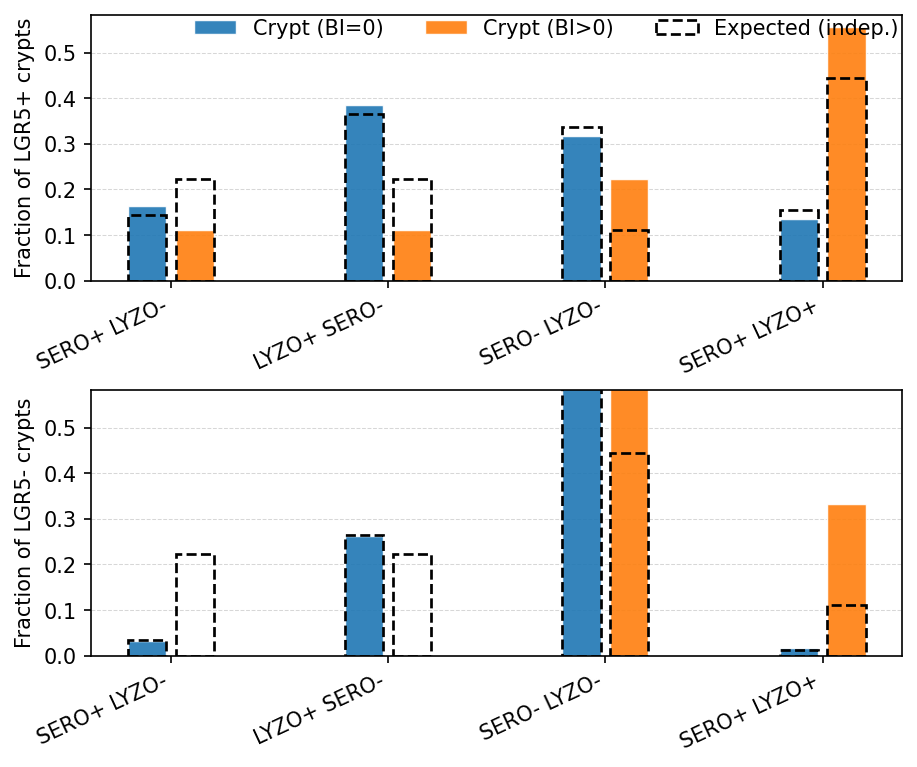

N crypts per plotted group: {'Crypt (BI=0)': 230, 'Crypt (BI>0)': 12}
N LGR5+ crypts per plotted group: {'Crypt (BI=0)': 104, 'Crypt (BI>0)': 9}
N LGR5- crypts per plotted group: {'Crypt (BI=0)': 126, 'Crypt (BI>0)': 3}


In [245]:
group_specs = [
    ("Crypt (BI=0)", lambda df: df["constriction"].to_numpy() == 0),
    ("Crypt (BI>0)", lambda df: df["constriction"].to_numpy() > 0),
]

# df_sel = inspection_df.query("timepoint == 'D3'").copy() # restrict to subset


plot_coexpression_from_inspection_table(
    inspection_df=inspection_df,
    marker_names=MARKER_NAMES,
    group_specs=group_specs,
    labels_cond=["SERO+ LYZO-", "LYZO+ SERO-", "SERO- LYZO-", "SERO+ LYZO+"],
    title="",
)

In [246]:
from organograph.crypts.analysis import bin_marker_positivity

def collect_binned_marker_profiles_from_table(
    inspection_df,
    bin_edges,
    marker_names=None,
    marker_subset=None,
    seg_path_col="seg_path",
    crypt_number_col="crypt_number",
    markers_key="markers_bin",
    crypts_key_candidates=("crypts_graph", "crypts_ll", "graph_crypts_ll"),
    distance_key="d_crypts_graph",
):
    """
    Collect per-crypt binned marker positivity profiles for the crypts selected
    in inspection_df.

    Uses:
        markers = markers_bin[crypt_cells]
        distance = seg[distance_key][crypt_idx]

    Returns
    -------
    dict with keys:
        "bin_edges"
        "bin_centers"
        "marker_names"
        "marker_subset"
        "marker_indices"
        "marker_pos_counts"   : list of (Msel, B)
        "marker_cell_counts"  : list of (B,)
        "meta"                : dataframe aligned to the lists above
    """
    bin_edges = np.asarray(bin_edges, dtype=float)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    df = inspection_df.dropna(subset=[seg_path_col, crypt_number_col]).copy()
    df[crypt_number_col] = df[crypt_number_col].astype(int)

    marker_pos_counts_all = []
    marker_cell_counts_all = []
    meta_rows = []

    resolved_marker_names = None
    resolved_marker_subset = None
    marker_indices = None

    for seg_path, df_seg in df.groupby(seg_path_col, sort=False):
        seg = load_graph_crypt_segmentation(seg_path)
        G = load_cell_graph(seg["graph_path"])

        crypts_graph = _as_list_of_lists(
            _seg_get(seg, *crypts_key_candidates, default=[])
        )
        d_crypts_graph = seg[distance_key]
        markers_bin = np.asarray(graph_get(G, markers_key))

        if resolved_marker_names is None:
            resolved_marker_names = _infer_marker_names(G, marker_names=marker_names)

            if marker_subset is None:
                resolved_marker_subset = list(resolved_marker_names)
            else:
                resolved_marker_subset = list(marker_subset)

            marker_indices = [resolved_marker_names.index(m) for m in resolved_marker_subset]

        for _, row in df_seg.iterrows():
            crypt_idx = int(row[crypt_number_col])
            crypt_cells = np.asarray(list(crypts_graph[crypt_idx]), dtype=np.int64)

            counts_pos, counts_tot = bin_marker_positivity(
                markers_bin[:, marker_indices],
                distance=seg[distance_key][crypt_idx],
                bin_edges=bin_edges,
            )

            marker_pos_counts_all.append(counts_pos)
            marker_cell_counts_all.append(counts_tot)
            meta_rows.append(row.to_dict())

    return {
        "bin_edges": bin_edges,
        "bin_centers": bin_centers,
        "marker_names": resolved_marker_names,
        "marker_subset": resolved_marker_subset,
        "marker_indices": marker_indices,
        "marker_pos_counts": marker_pos_counts_all,
        "marker_cell_counts": marker_cell_counts_all,
        "meta": pd.DataFrame(meta_rows).reset_index(drop=True),
    }

In [247]:
def lighten_color(rgb_or_hex, amount=0.55):
    import matplotlib.colors as mcolors
    c = np.array(mcolors.to_rgb(rgb_or_hex))
    return tuple((1 - amount) * c + amount * np.ones(3))


def mean_and_sem(frac_group):
    mu = np.nanmean(frac_group, axis=0)
    sd = np.nanstd(frac_group, axis=0, ddof=1)
    n = np.sum(np.isfinite(frac_group), axis=0)
    se = sd / np.sqrt(np.maximum(n, 1))
    return mu, se


def plot_binned_marker_profiles(
    binned_data,
    target_markers=None,
    group_masks=None,
    group_labels=None,
    group_colors=None,
    row_height=2.3,
    fig_width=6,
    ncols=2,
    ylabel="fraction of cells",
    xlabel=r"$d$ (normalized distance; neck at 1)",
):

    marker_subset = list(binned_data["marker_subset"])
    bin_centers = np.asarray(binned_data["bin_centers"])
    meta = binned_data["meta"]

    pos_flat = np.stack(binned_data["marker_pos_counts"], axis=0).astype(float)
    tot_flat = np.stack(binned_data["marker_cell_counts"], axis=0).astype(float)
    frac_flat = pos_flat / np.maximum(tot_flat[:, None, :], 1.0)

    if target_markers is None:
        target_markers = marker_subset
    target_markers = list(target_markers)
    target_indices = [marker_subset.index(m) for m in target_markers]

    if group_masks is None:
        group_masks = [np.ones(len(meta), dtype=bool)]
        group_labels = ["all"]
        group_colors = ["#1f77b4"]

    default_palette = {
        "LGR5": "#1f77b4",
        "AldoB": "#2ca02c",
        "Serotonin": "#d62728",
        "Lysozyme": "#9467bd",
    }

    n_markers = len(target_markers)
    nrows = int(np.ceil(n_markers / ncols))

    # 👇 dynamic figure height
    fig_height = row_height * nrows

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(fig_width, fig_height),
        sharex=False,
        constrained_layout=True,
    )

    axes = np.atleast_1d(axes).ravel()

    for ax, m_idx, marker_name in zip(axes, target_indices, target_markers):

        base = default_palette.get(marker_name, "#1f77b4")
        colors_this = [base, lighten_color(base, 0.55)] if len(group_masks) == 2 else group_colors

        for gmask, glabel, gcolor in zip(group_masks, group_labels, colors_this):

            mu, se = mean_and_sem(frac_flat[gmask, m_idx, :])

            ax.fill_between(bin_centers, mu - se, mu + se, color=gcolor, alpha=0.20, linewidth=0)
            ax.plot(bin_centers, mu, color=gcolor, linewidth=2.0,
                    label=f"{glabel} (N={int(np.sum(gmask))})")

        ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)
        ax.set_ylabel(ylabel)
        ax.set_ylim(bottom=0)

        ax.text(
            0.02, 0.98,
            marker_name,
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontweight="bold",
            fontsize=10,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.7),
        )

    for ax in axes[n_markers:]:
        ax.axis("off")

    for ax in axes[max(0, len(axes) - ncols):]:
        if ax.has_data():
            ax.set_xlabel(xlabel)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", frameon=False)

    plt.show()

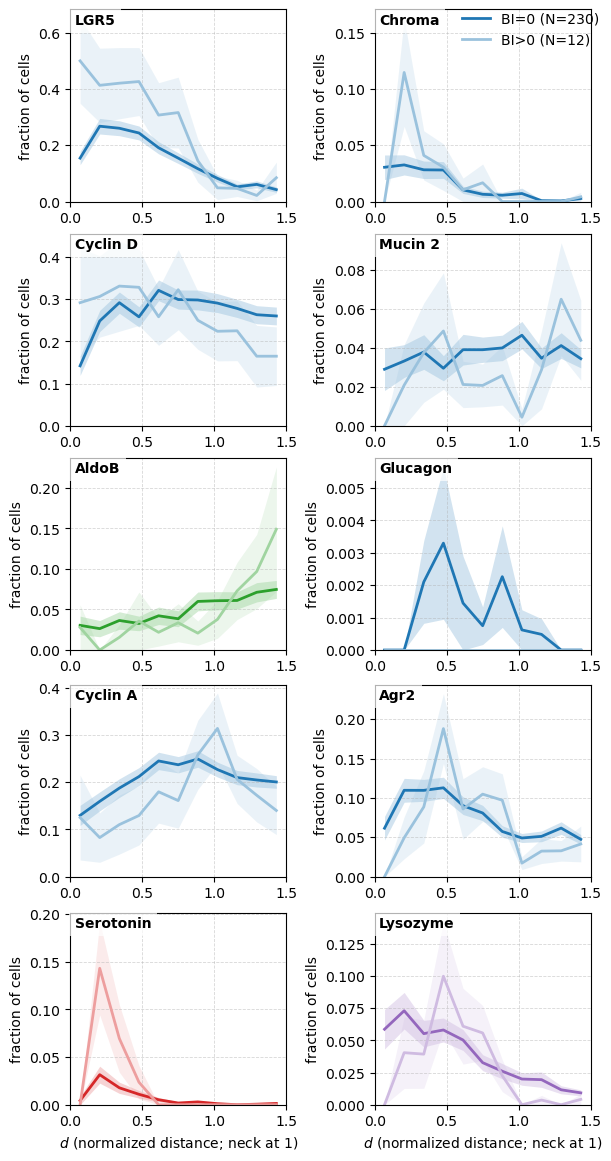

In [248]:
target_markers = None # ["LGR5", "AldoB", "Serotonin", "Lysozyme"]

bin_edges = np.linspace(0, 1.5, 12)

binned = collect_binned_marker_profiles_from_table(
    inspection_df=inspection_df,
    bin_edges=bin_edges,
    marker_names=MARKER_NAMES,
    marker_subset=target_markers,
)

meta = binned["meta"]
m_bulged = meta["constriction"].to_numpy() == 0
m_budded = meta["constriction"].to_numpy() > 0

plot_binned_marker_profiles(
    binned_data=binned,
    target_markers=target_markers,
    group_masks=[m_bulged, m_budded],
    group_labels=["BI=0", "BI>0"],
    group_colors=["#1f77b4", "#1f77b4"],
    ncols=2,
)